In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler


In [55]:
df=pd.read_csv("/content/weather_data.csv", on_bad_lines='skip')
df

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622
...,...,...,...,...,...,...
999995,Dallas,2024-01-01 20:29:48,23.416877,37.705024,3.819833,16.538119
999996,San Antonio,2024-01-20 15:59:48,6.759080,40.731036,8.182785,29.005558
999997,New York,2024-04-14 08:30:09,15.664465,62.201884,3.987558,0.403909
999998,Chicago,2024-05-12 20:10:43,18.999994,63.703245,4.294325,6.326036


In [56]:
df.shape


(1000000, 6)

In [57]:
df.describe()

,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,14.779705,60.021830,5.109639,14.997598
std,14.482558,17.324022,2.947997,8.663556
min,-19.969311,30.000009,0.000009,0.000051
25%,2.269631,45.008500,2.580694,7.490101
50%,14.778002,60.018708,5.109917,14.993777
75%,27.270489,75.043818,7.613750,22.514110
max,39.999801,89.999977,14.971583,29.999973


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 6 columns):
 #   Column            Non-Null Count    Dtype  
---  ------            --------------    -----  
 0   Location          1000000 non-null  object 
 1   Date_Time         1000000 non-null  object 
 2   Temperature_C     1000000 non-null  float64
 3   Humidity_pct      1000000 non-null  float64
 4   Precipitation_mm  1000000 non-null  float64
 5   Wind_Speed_kmh    1000000 non-null  float64
dtypes: float64(4), object(2)
memory usage: 45.8+ MB


In [89]:
df.duplicated().sum()
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)

In [60]:
df['Date_Time'] = pd.to_datetime(df['Date_Time'], errors='coerce')

In [61]:
df['day'] = df['Date_Time'].dt.day
df['month'] = df['Date_Time'].dt.month
df['year'] = df['Date_Time'].dt.year
df['hour'] = df['Date_Time'].dt.hour

In [62]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

In [63]:
df['day_sin'] = np.sin(2 * np.pi * df['day'] / 31)
df['day_cos'] = np.cos(2 * np.pi * df['day'] / 31)

In [64]:
encoder = OneHotEncoder(sparse_output=False)
encoded = encoder.fit_transform(df[['Location']])

encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(['Location']))
df = pd.concat([df, encoded_df], axis=1)

In [65]:
df.head()

,Location,Date_Time,Temperature_C,Humidity_pct,Precipitation_mm,Wind_Speed_kmh,day,month,year,hour,...,Location_Chicago,Location_Dallas,Location_Houston,Location_Los Angeles,Location_New York,Location_Philadelphia,Location_Phoenix,Location_San Antonio,Location_San Diego,Location_San Jose
0,San Diego,2024-01-14 21:12:46,10.683001,41.195754,4.020119,8.233540,14,1,2024,21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,San Diego,2024-05-17 15:22:10,8.734140,58.319107,9.111623,27.715161,17,5,2024,15,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,San Diego,2024-05-11 09:30:59,11.632436,38.820175,4.607511,28.732951,11,5,2024,9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,Philadelphia,2024-02-26 17:32:39,-8.628976,54.074474,3.183720,26.367303,26,2,2024,17,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,San Antonio,2024-04-29 13:23:51,39.808213,72.899908,9.598282,29.898622,29,4,2024,13,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [66]:
df.to_csv('cleaned_data.csv', index=False)

In [67]:
location_columns = [col for col in df.columns if col.startswith('Location_')]

In [68]:
X = df[['day','month','year','hour',
        'month_sin','month_cos','day_sin','day_cos'] + location_columns]

y = df[['Temperature_C','Humidity_pct','Precipitation_mm','Wind_Speed_kmh']]

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [70]:
X_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled  = X_scaler.transform(X_test)

Temperature_scaler = MinMaxScaler().fit(y_train[['Temperature_C']])
Humidity_scaler    = MinMaxScaler().fit(y_train[['Humidity_pct']])
Prec_scaler        = MinMaxScaler().fit(y_train[['Precipitation_mm']])
Wind_scaler        = MinMaxScaler().fit(y_train[['Wind_Speed_kmh']])

y_train_scaled = np.hstack([
    Temperature_scaler.transform(y_train[['Temperature_C']]),
    Humidity_scaler.transform(y_train[['Humidity_pct']]),
    Prec_scaler.transform(y_train[['Precipitation_mm']]),
    Wind_scaler.transform(y_train[['Wind_Speed_kmh']])
])

y_test_scaled = np.hstack([
    Temperature_scaler.transform(y_test[['Temperature_C']]),
    Humidity_scaler.transform(y_test[['Humidity_pct']]),
    Prec_scaler.transform(y_test[['Precipitation_mm']]),
    Wind_scaler.transform(y_test[['Wind_Speed_kmh']])
])

In [71]:
LSTM_MODEL = {
    "X_scaler": X_scaler,
    "y_scalers": {
        "Temperature_C": Temperature_scaler,
        "Humidity_pct": Humidity_scaler,
        "Precipitation_mm": Prec_scaler,
        "Wind_Speed_kmh": Wind_scaler
    }
}

with open('LSTM_MODEL.pk3', 'wb') as f:
    pickle.dump(LSTM_MODEL, f)

In [72]:
output_columns = ['Temperature_C','Humidity_pct','Precipitation_mm','Wind_Speed_kmh']
y=df[output_columns].values

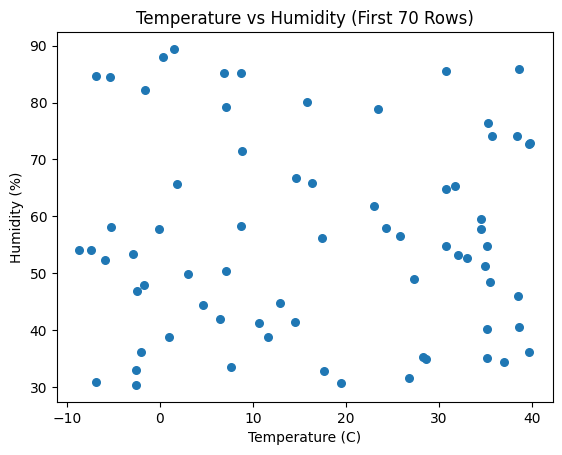

In [73]:
df_small = df.head(70)
plt.scatter(df_small['Temperature_C'], df_small['Humidity_pct'], s=30)
plt.xlabel("Temperature (C)")
plt.ylabel("Humidity (%)")
plt.title("Temperature vs Humidity (First 70 Rows)")
plt.show()

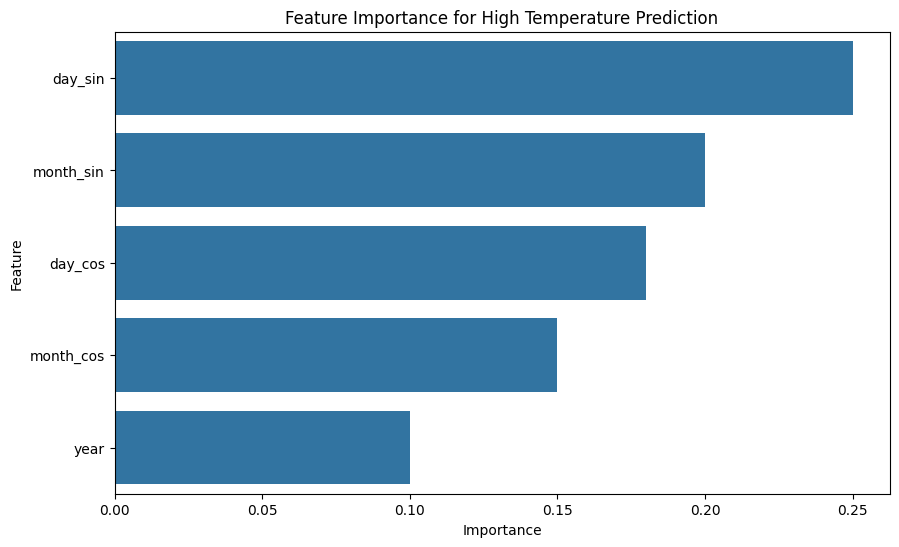

In [74]:
selected_features = ['month_sin','month_cos','day_sin','day_cos','year']
importances = [0.2, 0.15, 0.25, 0.18, 0.1]

feature_importance_df = pd.DataFrame({'Feature': selected_features, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importance for High Temperature Prediction')
plt.show()

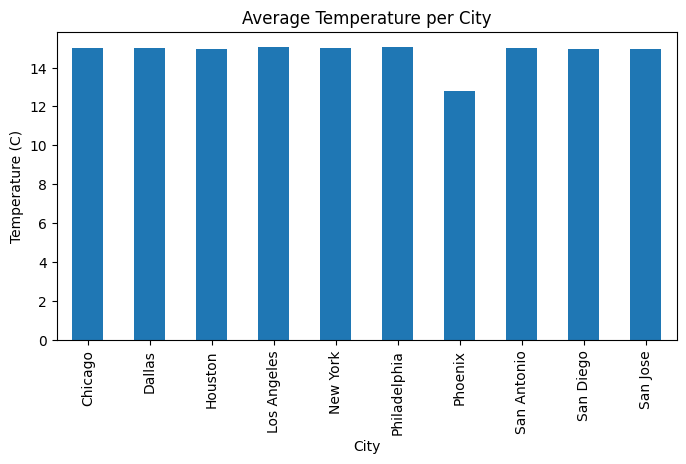

In [75]:
city_avg = df.groupby('Location')['Temperature_C'].mean()

plt.figure(figsize=(8, 4))
city_avg.plot(kind='bar')
plt.title('Average Temperature per City')
plt.ylabel('Temperature (C)')
plt.xlabel('City')
plt.show()


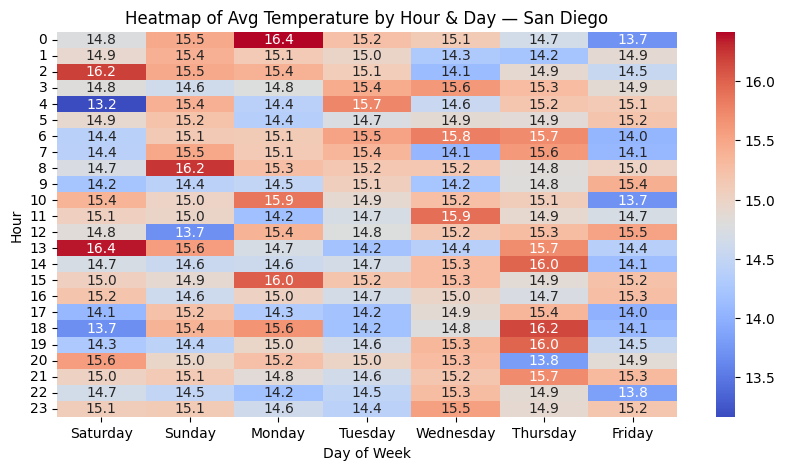

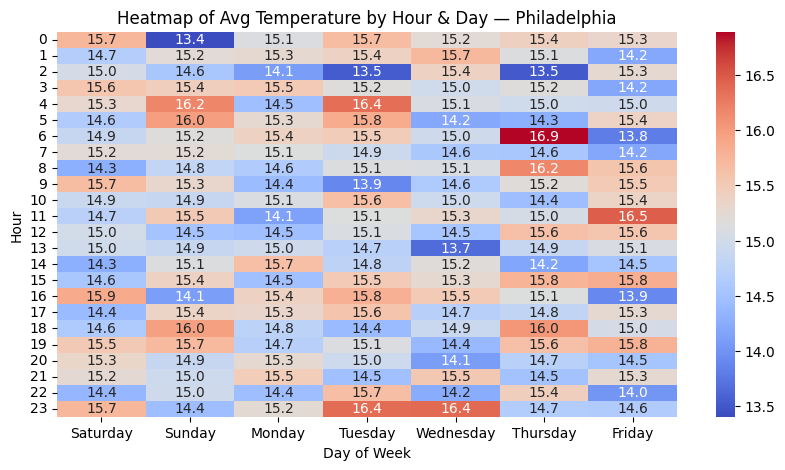

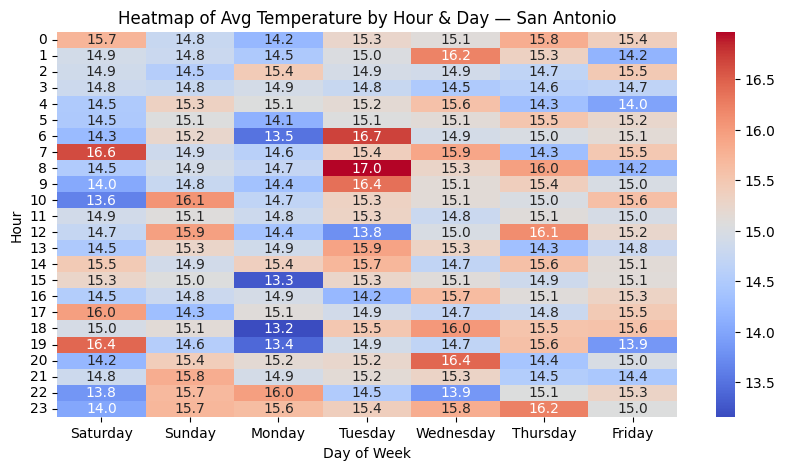

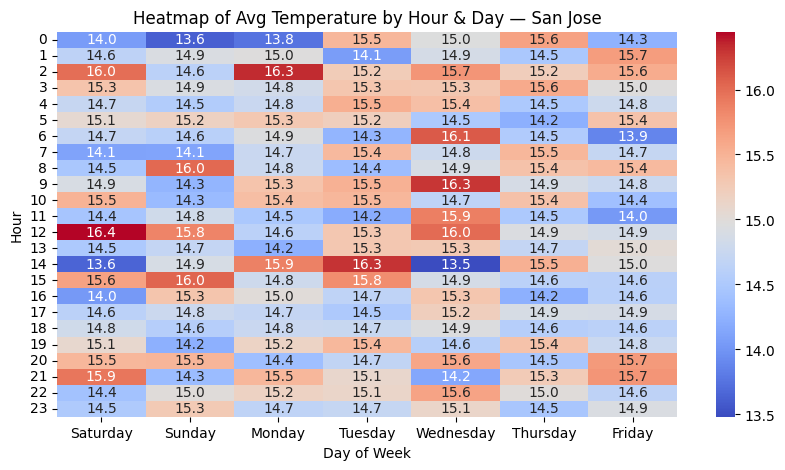

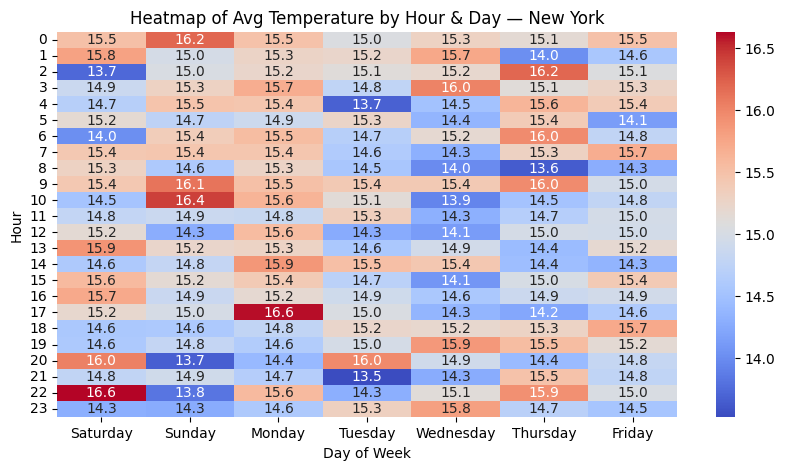

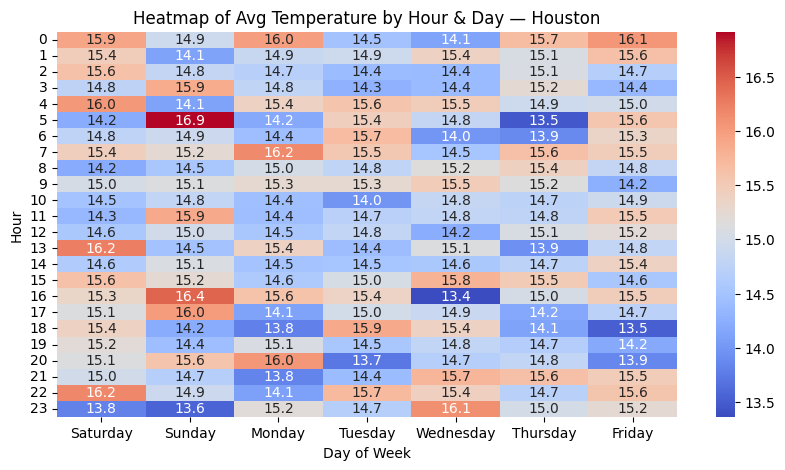

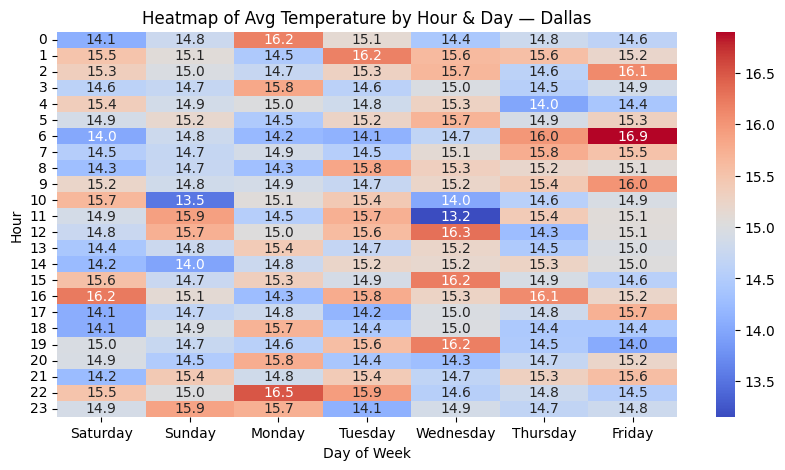

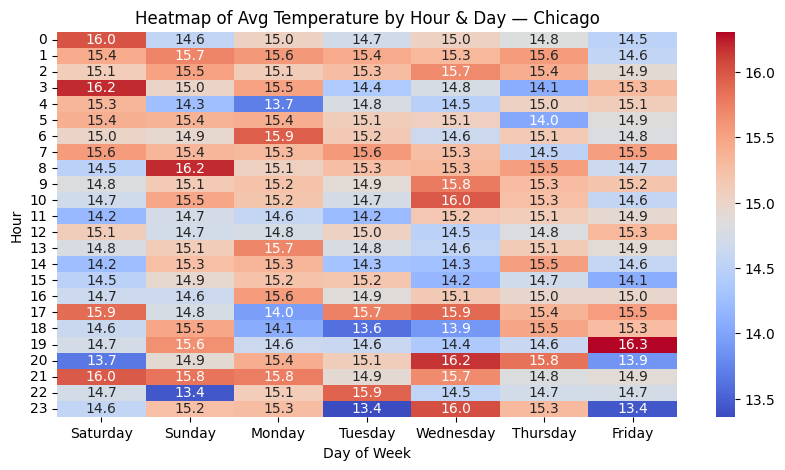

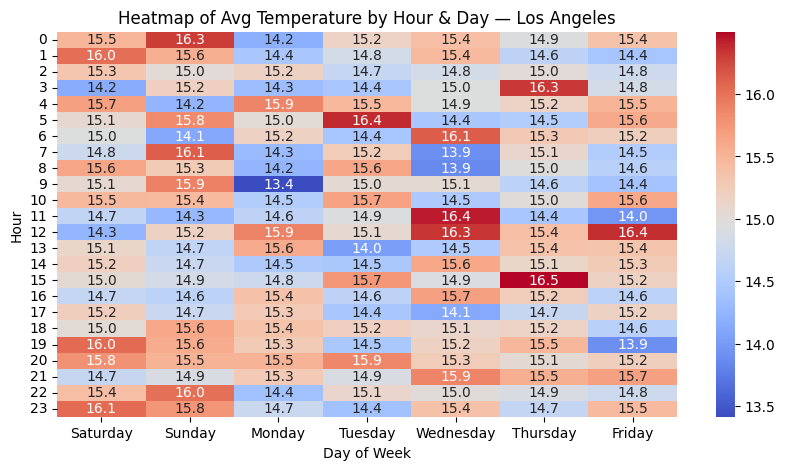

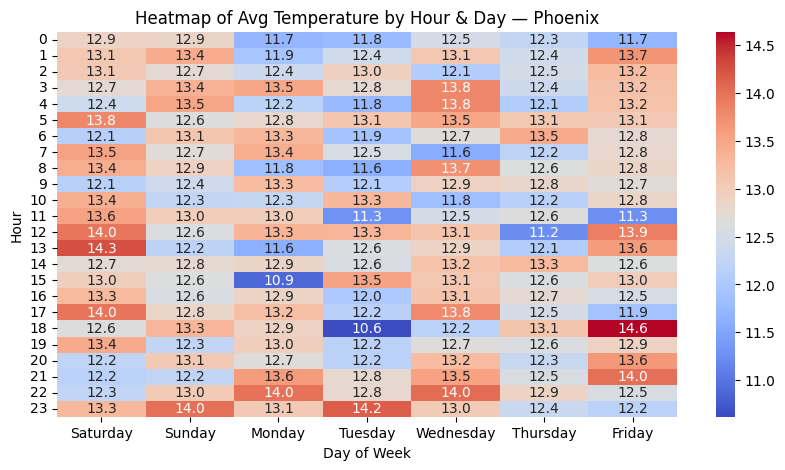

In [76]:
cities = df['Location'].unique()
df['day_of_week'] = df['Date_Time'].dt.day_name()
days_order = ['Saturday','Sunday','Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday' ]

for city in cities:
    city_df = df[df['Location'] == city]
    pivot_table = city_df.pivot_table(
        values='Temperature_C',
        index='hour',
        columns='day_of_week',
        aggfunc='mean'
    ).reindex(columns=days_order)

    plt.figure(figsize=(10, 5))
    sns.heatmap(pivot_table, cmap='coolwarm', annot=True, fmt=".1f")
    plt.title(f'Heatmap of Avg Temperature by Hour & Day — {city}')
    plt.xlabel('Day of Week')
    plt.ylabel('Hour')
    plt.show()

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Reshape
from tensorflow.keras.callbacks import EarlyStopping

In [78]:
model = Sequential([
    # نعمل reshape جوّا الموديل بدل برا
    Reshape((1, X_train_scaled.shape[1]), input_shape=(X_train_scaled.shape[1],)),

    LSTM(128, return_sequences=True),
    Dropout(0.2),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(4, activation='linear')   # لأنه عندك 4 قيم target
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape_3 (Reshape)             │ (None, 1, 18)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 1, 128)         │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 126,884 (495.64 KB)

 Trainable params: 126,884 (495.64 KB)

 Non-trainable params: 0 (0.00 B)

In [79]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [81]:
history = model.fit(
    X_train_scaled, y_train_scaled,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 67s 7ms/step - loss: 0.0657 - mae: 0.2191 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 2/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 66s 7ms/step - loss: 0.0656 - mae: 0.2191 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 3/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 66s 7ms/step - loss: 0.0656 - mae: 0.2191 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 4/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 67s 7ms/step - loss: 0.0657 - mae: 0.2193 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 5/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step - loss: 0.0657 - mae: 0.2193 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 6/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 68s 7ms/step - loss: 0.0657 - mae: 0.2192 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 7/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step - loss: 0.0657 - mae: 0.2193 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 8/30
10000/10000 ━━━━━━━━━━━━━━━━━━━━ 69s 7ms/step - loss: 0.0657 - mae: 0.2192 - val_loss: 0.0656 - val_mae: 0.2191
Epoch 9/30
10000

In [91]:
y_pred_scaled = model.predict(X_test_scaled)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step


In [83]:
loss, mae = model.evaluate(X_test_scaled, y_test_scaled)
print("Test MSE:", loss)
print("Test MAE:", mae)

6250/6250 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - loss: 0.0656 - mae: 0.2191
Test MSE: 0.06555838137865067
Test MAE: 0.219021275639534


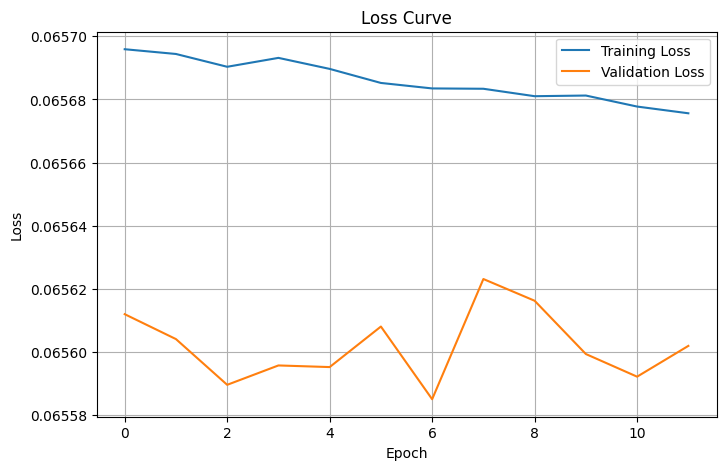

In [92]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [93]:
model.save("lstm_model.h5")
print("Model saved!")


Model saved!
